In [1]:
import sys
import os
from pathlib import Path

import torch

sys.path.append(os.path.abspath("../src"))

from models import MobileNetV2

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [5]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [6]:
train_loader, val_loader, test_loader = prepare_data(df)

device = get_device()

model = MobileNetV2(num_classes=2, in_channels=1).to(device)

criterion, optimizer = setup_training(model)

Using MPS (GPU)


In [7]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "mobilenetv2_binary_target", 3)

Val Epoch 1: 100%|██████████| 1055/1055 [04:28<00:00,  3.93it/s, avg_acc=0.5702, avg_loss=0.6943]


Epoch 1/10 | ETA (Remaining): 04:27:48 | Total ETA: 04:57:33
  Train Loss: 0.6769 | Train Acc: 0.5801
  Val Loss: 0.6943 | Val Acc: 0.5702
  Val Precision: 0.6776
  Val Recall: 0.1101 | Val F1: 0.1894
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/mobilenetv2_binary_target.pt
------------------------------------------------------------


Val Epoch 2: 100%|██████████| 1055/1055 [04:26<00:00,  3.95it/s, avg_acc=0.6480, avg_loss=0.6354]


Epoch 2/10 | ETA (Remaining): 03:56:10 | Total ETA: 04:57:33
  Train Loss: 0.6526 | Train Acc: 0.6246
  Val Loss: 0.6354 | Val Acc: 0.6480
  Val Precision: 0.6439
  Val Recall: 0.5107 | Val F1: 0.5696
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/mobilenetv2_binary_target.pt
------------------------------------------------------------


Val Epoch 3: 100%|██████████| 1055/1055 [04:56<00:00,  3.56it/s, avg_acc=0.6661, avg_loss=0.6234]


...

Epoch 5/10 | ETA (Remaining): 02:25:21 | Total ETA: 04:57:33
  Train Loss: 0.6182 | Train Acc: 0.6694
  Val Loss: 0.6140 | Val Acc: 0.6738
  Val Precision: 0.6536
  Val Recall: 0.6059 | Val F1: 0.6289
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Val Epoch 6: 100%|██████████| 1055/1055 [04:29<00:00,  3.92it/s, avg_acc=0.6803, avg_loss=0.6070]


Epoch 6/10 | ETA (Remaining): 01:55:31 | Total ETA: 04:57:33
  Train Loss: 0.6104 | Train Acc: 0.6779
  Val Loss: 0.6070 | Val Acc: 0.6803
  Val Precision: 0.6649
  Val Recall: 0.6027 | Val F1: 0.6323
------------------------------------------------------------
No improvement. Patience: 2/3
------------------------------------------------------------


Val Epoch 7: 100%|██████████| 1055/1055 [04:27<00:00,  3.94it/s, avg_acc=0.6790, avg_loss=0.6100]


Epoch 7/10 | ETA (Remaining): 01:26:09 | Total ETA: 04:57:33
  Train Loss: 0.6036 | Train Acc: 0.6843
  Val Loss: 0.6100 | Val Acc: 0.6790
  Val Precision: 0.6505
  Val Recall: 0.6402 | Val F1: 0.6453
------------------------------------------------------------
No improvement. Patience: 3/3
------------------------------------------------------------
Early stopping at epoch 7 (patience 3 exceeded)


(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

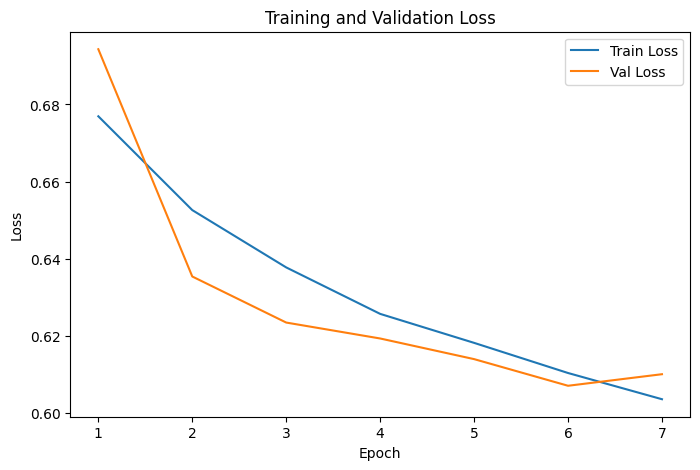

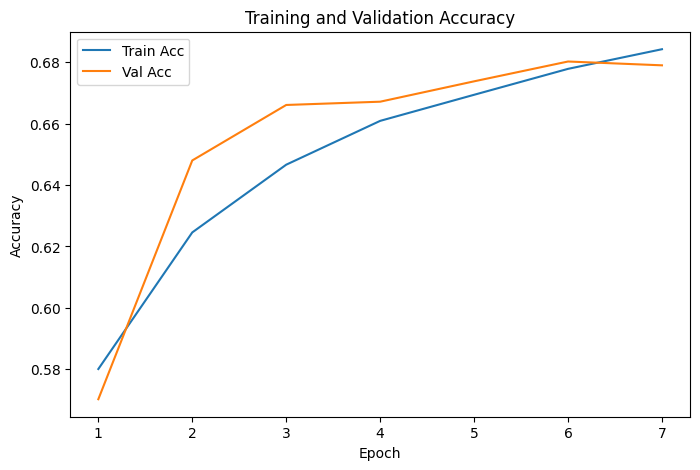

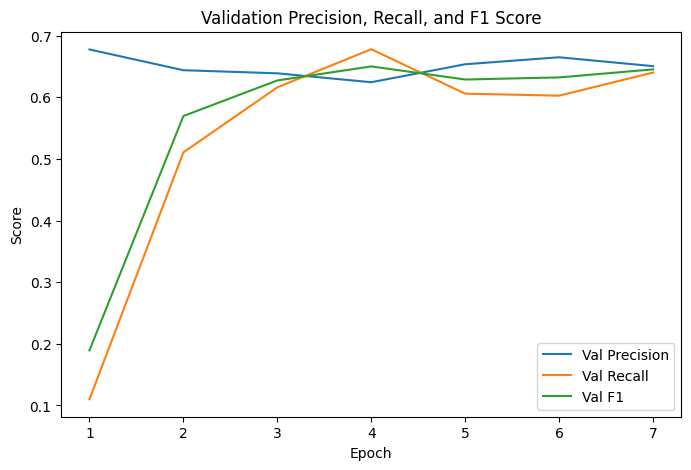

In [8]:
plot_training_history(history)

In [9]:
save_path = get_model_path("mobilenetv2_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = MobileNetV2(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/mobilenetv2_binary_target.pt


Val: 100%|██████████| 1020/1020 [04:21<00:00,  3.90it/s, avg_acc=0.6704, avg_loss=0.6145]


Test Results
  Loss: 0.6145
  Accuracy: 0.6704
  Precision: 0.6316
  Recall: 0.6879
  F1 Score: 0.6586


In [27]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"], "({:.2f}%)".format(result["probabilities"][result["predicted_class"]]*100))
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])

Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_008/images/00017078_002.png
Predicted class: normal (56.68%)
True label: normal
Probabilities: {'normal': 0.5667683482170105, 'abnormal': 0.4332316815853119}
